In [1]:
import dataclasses
import logging
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import mne
import seaborn as sns

# Resolve project root regardless of where the notebook is launched from
for _candidate in [".", "..", "../.."]:  # noqa: B007
    _p = os.path.abspath(_candidate)
    if os.path.isdir(os.path.join(_p, "src")):
        sys.path.insert(0, _p)
        break

from scripts.analysis_common import (  # noqa: E402
    FREQUENCY_BANDS,
    _WAVELET_BAND_FREQ_RESOLUTION_HZ,
    _wavelet_transform,
    analyzers_to_datasets,
    load_analyzers,
)
from mne.viz import plot_topomap  # noqa: E402
from src.analysis.isc import compute_loo_isc, compute_sliding_window_isc  # noqa: E402
from src.analysis.mean_variance import compute_intersubject_stats  # noqa: E402
from src.definitions.constants import ProjectPaths  # noqa: E402
from src.definitions.fields import (  # noqa: E402
    ConditionVariants,
    ExclusionCategories,
    MusicTypeVariants,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
%matplotlib inline

# Wavelet Power Exploration

Exploratory analysis of **wavelet-transformed EEG data** (power representation).

This notebook loads pre-computed (or freshly computed) wavelet transforms in 4-D
format `(n_subjects, n_channels, n_frequencies, n_times)` and runs the following
sketch analyses:

1. Grand-average spectral profile
2. Time–frequency map (spectrogram)
3. Per-band power time course
4. Intersubject variance in the wavelet domain
5. Wavelet-domain LOO-ISC (per band)

See `README.md` in this directory for the rationale behind each step and ideas
for future extensions.

## Configuration

In [2]:
# ── Experiment configuration ─────────────────────────────────────────────────
CONDITION = ConditionVariants.PLACEBO
MUSIC_TYPES = [MusicTypeVariants.CLASSICAL]  # single type for fast exploration
EXCLUSION_CATEGORIES = [ExclusionCategories.BAD_MUSIC, ExclusionCategories.ARTIFACTS]
PROCESS_AND_SAVE_DATA = False  # set True to re-process raw files

# ── Wavelet settings ─────────────────────────────────────────────────────────
REPRESENTATION = "power"
WAVELET_FREQ_MIN = min(lo for lo, _ in FREQUENCY_BANDS.values())
WAVELET_FREQ_MAX = max(hi for _, hi in FREQUENCY_BANDS.values())
WAVELET_N_FREQS = max(
    2,
    int(round((WAVELET_FREQ_MAX - WAVELET_FREQ_MIN) / _WAVELET_BAND_FREQ_RESOLUTION_HZ))
    + 1,
)
FREQS = np.linspace(WAVELET_FREQ_MIN, WAVELET_FREQ_MAX, WAVELET_N_FREQS)

KEEP_FREQUENCY_DIM = True
RESHAPE_FREQUENCY_DIM = True  # -> (n_subjects, n_channels, n_freqs, n_times)

# ── Reuse / compute ──────────────────────────────────────────────────────────
REUSE_WAVELETS = True  # load from cache; set False to compute + save

# ── Subject subset ────────────────────────────────────────────────────────────
# Always limit to the first N individuals (fast interactive exploration).
# Set to None to use all subjects.
N_SUBJECTS_SUBSET: int | None = 5

# ── Channel and time subset ───────────────────────────────────────────────────
# Slice the EEG data before wavelet computation.  The small subset is stored
# in the wavelet cache so subsequent runs simply reload from disk without any
# re-computation.  Set to None to disable the respective slicing.
N_CHANNELS_SUBSET: int | None = 32  # first N channels (from 195)
N_TIMES_SUBSET: int | None = 10000  # first N time samples (from ~91 000)

# ── Scope ─────────────────────────────────────────────────────────────────────
RUN_BROADBAND = True
RUN_PER_BAND = True

# ── Storage directory (notebook-local cache, avoids large processed-data writes) ────
WAVELET_DIR: Path = ProjectPaths.NOTEBOOKS_DIR / "03-wavelet-analysis" / "wavelet_cache"

# ── Plot saving ──────────────────────────────────────────────────────────────
SAVE_PLOTS = True
PLOT_PERCENTILE_CLIP: int = 99  # clip upper percentile in mean/variance plots
PLOTS_DIR = ProjectPaths.NOTEBOOKS_DIR / "03-wavelet-analysis" / "plots" / "power"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Wavelet base directory : {WAVELET_DIR}")
print(
    f"Frequencies            : {FREQS[0]:.1f}–{FREQS[-1]:.1f} Hz ({len(FREQS)} steps)"
)
print(f"Reshape to 4D          : {RESHAPE_FREQUENCY_DIM}")
print(
    "Subject subset         : "
    + (
        f"{N_SUBJECTS_SUBSET} individuals"
        if N_SUBJECTS_SUBSET is not None
        else "all individuals"
    )
)
print(
    "Channel subset         : "
    + (
        f"{N_CHANNELS_SUBSET} channels"
        if N_CHANNELS_SUBSET is not None
        else "all channels"
    )
)
print(
    "Time subset            : "
    + (f"{N_TIMES_SUBSET} samples" if N_TIMES_SUBSET is not None else "all samples")
)

Wavelet base directory : /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/03-wavelet-analysis/wavelet_cache
Frequencies            : 1.0–70.0 Hz (70 steps)
Reshape to 4D          : True
Subject subset         : 5 individuals
Channel subset         : 32 channels
Time subset            : 10000 samples


## Data Loading

In [3]:
analyzers = load_analyzers(
    MUSIC_TYPES,
    CONDITION,
    EXCLUSION_CATEGORIES,
    PROCESS_AND_SAVE_DATA,
    normalize_data=False,
)
datasets = analyzers_to_datasets(analyzers)

# Always limit to first N_SUBJECTS_SUBSET individuals
if N_SUBJECTS_SUBSET is not None:
    datasets = {
        label: dataclasses.replace(ad, data=ad.data[:N_SUBJECTS_SUBSET])
        for label, ad in datasets.items()
    }
    print(f"Using first {N_SUBJECTS_SUBSET} individuals.")

# Slice to channel subset
if N_CHANNELS_SUBSET is not None:
    datasets = {
        label: dataclasses.replace(ad, data=ad.data[:, :N_CHANNELS_SUBSET, :])
        for label, ad in datasets.items()
    }
    print(f"Using first {N_CHANNELS_SUBSET} channels.")

# Slice to time subset
if N_TIMES_SUBSET is not None:
    datasets = {
        label: dataclasses.replace(ad, data=ad.data[:, :, :N_TIMES_SUBSET])
        for label, ad in datasets.items()
    }
    print(f"Using first {N_TIMES_SUBSET} time samples.")

print("Loaded datasets:", list(datasets.keys()))
for label, ad in datasets.items():
    print(
        f"  {label}: {ad.n_items} subjects, {ad.n_features} channels, {ad.n_samples} samples"
    )

INFO src.analysis.summary.EEGSummarizedAnalyzer: Data loaded from /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/concatenated/Placebo_CLASSIC.npy  (shape=(15, 195, 91392))


Opening raw data file /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI035_EEGB_MUSIC_CLASSIC_EC_20180209_124821.fif...
    Range : 19254 ... 384821 =     19.254 ...   384.821 secs
Ready.


/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/src/io/loading.py:110: RuntimeWarning: This filename (/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI035_EEGB_MUSIC_CLASSIC_EC_20180209_124821.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(
INFO scripts.analysis_common: [Placebo_CLASSIC] Loaded data shape: (15, 195, 91392)
INFO scripts.analysis_common: [Placebo_CLASSIC] AnalysisData('Placebo_CLASSIC', time_domain, 15 items × 195 features × 91392 samples, sfreq=250.0)


Using first 5 individuals.
Using first 32 channels.
Using first 10000 time samples.
Loaded datasets: ['Placebo_CLASSIC']
  Placebo_CLASSIC: 5 subjects, 32 channels, 10000 samples


## Load or compute wavelet transforms

### Broadband

Stored in `WAVELET_DIR/broadband/`.

In [4]:
broadband_datasets: dict = {}

if RUN_BROADBAND:
    broadband_datasets = _wavelet_transform(
        datasets=datasets,
        freqs=FREQS,
        representation=REPRESENTATION,
        keep_frequency_dim=KEEP_FREQUENCY_DIM,
        reshape_frequency_dim=RESHAPE_FREQUENCY_DIM,
        wavelet_dir=WAVELET_DIR / "broadband",
        reuse_wavelets=REUSE_WAVELETS,
    )
    for label, ad in broadband_datasets.items():
        source = ad.metadata.get("loaded_from_wavelet_file", "computed_now")
        print(f"[broadband] {label}: shape={ad.data.shape}  source={source}")

[broadband] Placebo_CLASSIC: shape=(5, 32, 70, 10000)  source=/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/03-wavelet-analysis/wavelet_cache/broadband/Placebo_CLASSIC__wavelet_power__1.000_70.000_70__freqdim1.npz


### Per-band

Each EEG band is stored in `WAVELET_DIR/band_<name>/`.

In [5]:
band_datasets: dict[str, dict] = {}  # band_name -> {label: AnalysisData}

if RUN_PER_BAND:
    for band, (l_freq, h_freq) in FREQUENCY_BANDS.items():
        n_freqs = max(
            2,
            int(round((h_freq - l_freq) / _WAVELET_BAND_FREQ_RESOLUTION_HZ)) + 1,
        )
        band_freqs = np.linspace(l_freq, h_freq, n_freqs)
        band_datasets[band] = _wavelet_transform(
            datasets=datasets,
            freqs=band_freqs,
            representation=REPRESENTATION,
            keep_frequency_dim=KEEP_FREQUENCY_DIM,
            reshape_frequency_dim=RESHAPE_FREQUENCY_DIM,
            wavelet_dir=WAVELET_DIR / f"band_{band}",
            reuse_wavelets=REUSE_WAVELETS,
        )
        for label, ad in band_datasets[band].items():
            source = ad.metadata.get("loaded_from_wavelet_file", "computed_now")
            print(f"[{band:6s}] {label}: shape={ad.data.shape}  source={source}")

[delta ] Placebo_CLASSIC: shape=(5, 32, 4, 10000)  source=/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/03-wavelet-analysis/wavelet_cache/band_delta/Placebo_CLASSIC__wavelet_power__1.000_4.000_4__freqdim1.npz
[theta ] Placebo_CLASSIC: shape=(5, 32, 5, 10000)  source=/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/03-wavelet-analysis/wavelet_cache/band_theta/Placebo_CLASSIC__wavelet_power__4.000_8.000_5__freqdim1.npz
[alpha ] Placebo_CLASSIC: shape=(5, 32, 6, 10000)  source=/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/03-wavelet-analysis/wavelet_cache/band_alpha/Placebo_CLASSIC__wavelet_power__8.000_13.000_6__freqdim1.npz
[beta  ] Placebo_CLASSIC: shape=(5, 32, 18, 10000)  source=/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/03-wavelet-analysis/wavelet_cache/band_beta/Placebo_CLASSIC__wavelet_power__13.000_30.000_18__freqdim1.npz
[gamma ] Placebo_CLASSIC: shape=(5, 32, 41, 10000)  source=/auto/vestec1-elixir/home/dbeinhauer/

## Dataset Selection

Change `LABEL` to switch between music types.  The remaining cells use `bb_data`
(broadband, 4-D) and the derived scalars.

In [6]:
LABEL = list(broadband_datasets.keys())[0]
# LABEL = list(broadband_datasets.keys())[1]  # uncomment for second music type

bb_ad = broadband_datasets[LABEL]
bb_data = bb_ad.data  # (n_subjects, n_channels, n_freqs, n_times)
sfreq = bb_ad.sfreq

n_subjects, n_channels, n_freqs, n_times = bb_data.shape
time = np.arange(n_times) / sfreq

print(f"Dataset    : {LABEL}")
print(f"Shape      : {bb_data.shape}  (subjects × channels × freqs × times)")
print(f"Duration   : {n_times / sfreq:.1f} s  @  {sfreq} Hz")
print(f"Freq range : {FREQS[0]:.1f}–{FREQS[-1]:.1f} Hz ({n_freqs} steps)")

Dataset    : Placebo_CLASSIC
Shape      : (5, 32, 70, 10000)  (subjects × channels × freqs × times)
Duration   : 40.0 s  @  250.0 Hz
Freq range : 1.0–70.0 Hz (70 steps)


---
## 1 — Grand-Average Spectral Profile

Average wavelet power across subjects and time → `(n_channels, n_freqs)`;
then average over channels → `(n_freqs,)` spectrum.

Provides a sanity check: classical EEG peaks (alpha ~10 Hz) should be visible.

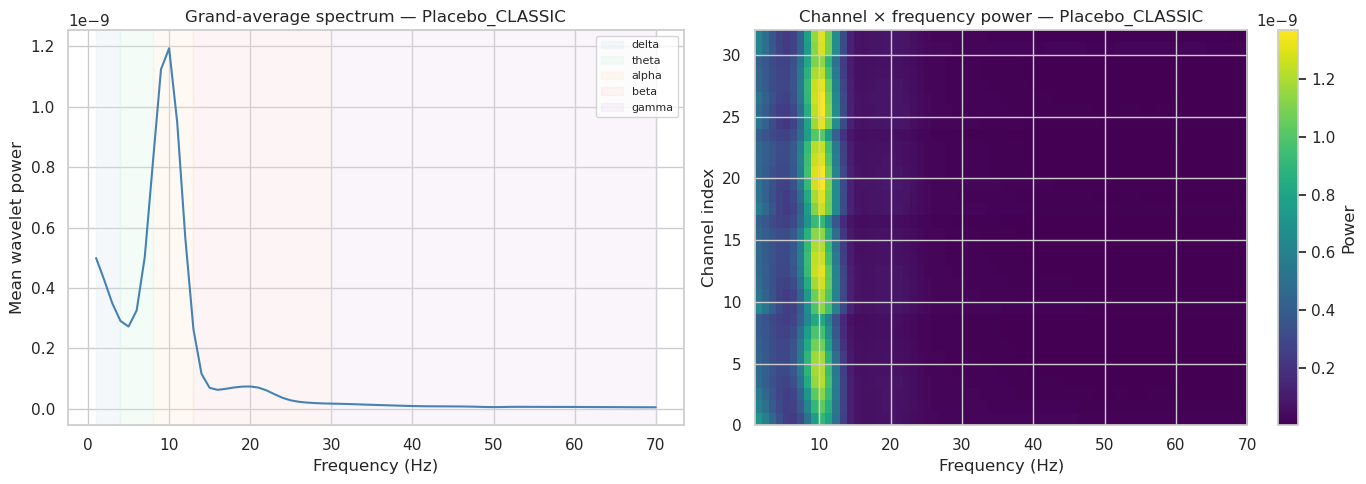

In [7]:
# Grand average: mean over subjects & time → (n_channels, n_freqs)
grand_avg_ch_freq = bb_data.mean(axis=(0, 3))  # (n_channels, n_freqs)
# Channel average → (n_freqs,)
grand_avg_spectrum = grand_avg_ch_freq.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: spectrum
axes[0].plot(FREQS, grand_avg_spectrum, color="steelblue", linewidth=1.5)
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Mean wavelet power")
axes[0].set_title(f"Grand-average spectrum — {LABEL}")
# Shade canonical bands
band_colors = {
    "delta": "#d4e6f1",
    "theta": "#d5f5e3",
    "alpha": "#fdebd0",
    "beta": "#fadbd8",
    "gamma": "#e8daef",
}
for band, (lo, hi) in FREQUENCY_BANDS.items():
    axes[0].axvspan(lo, hi, alpha=0.25, color=band_colors.get(band, "grey"), label=band)
axes[0].legend(fontsize=8, loc="upper right")

# Panel B: channel × frequency image
im = axes[1].imshow(
    grand_avg_ch_freq,
    aspect="auto",
    origin="lower",
    extent=[FREQS[0], FREQS[-1], 0, n_channels],
    cmap="viridis",
)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Channel index")
axes[1].set_title(f"Channel × frequency power — {LABEL}")
fig.colorbar(im, ax=axes[1], label="Power")

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "spectral_profile.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 2 — Time–Frequency Map (Spectrogram)

Channel-averaged and subject-averaged wavelet power as a 2-D image
`(n_freqs × n_times)`.  Reveals how spectral content evolves over the stimulus.

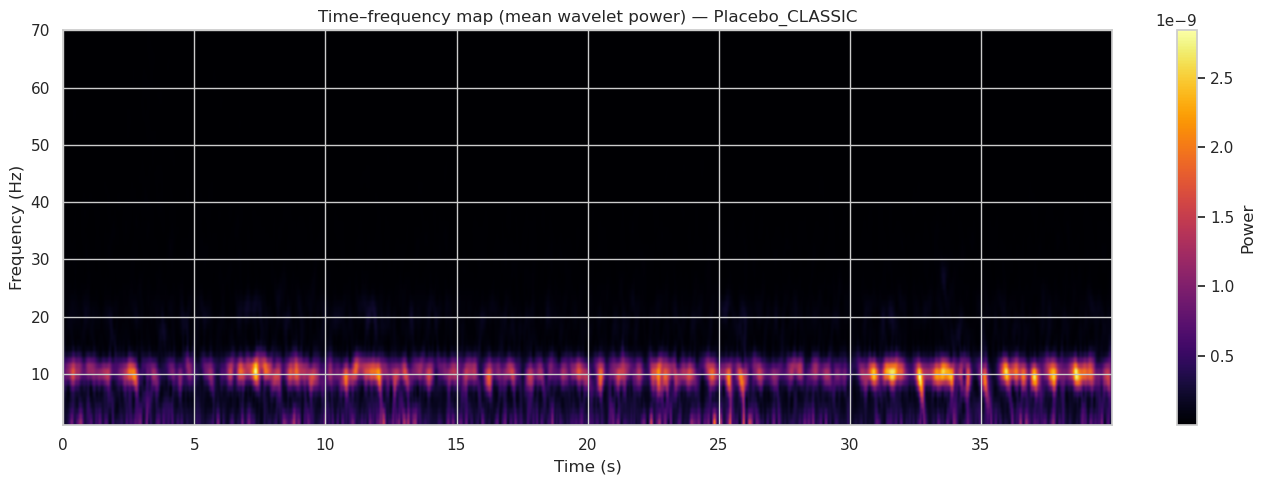

In [8]:
# Average over subjects and channels → (n_freqs, n_times)
tfr_map = bb_data.mean(axis=(0, 1))  # (n_freqs, n_times)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(
    tfr_map,
    aspect="auto",
    origin="lower",
    extent=[time[0], time[-1], FREQS[0], FREQS[-1]],
    cmap="inferno",
)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title(f"Time–frequency map (mean wavelet power) — {LABEL}")
fig.colorbar(im, ax=ax, label="Power")

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "time_frequency_map.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3 — Per-Band Power Time Course

For each band, average wavelet power over the band's frequency bins, then compute
the channel-averaged group mean ± SD across subjects.  Directly comparable to the
broadband time series in notebook `01-*` but now frequency-resolved.

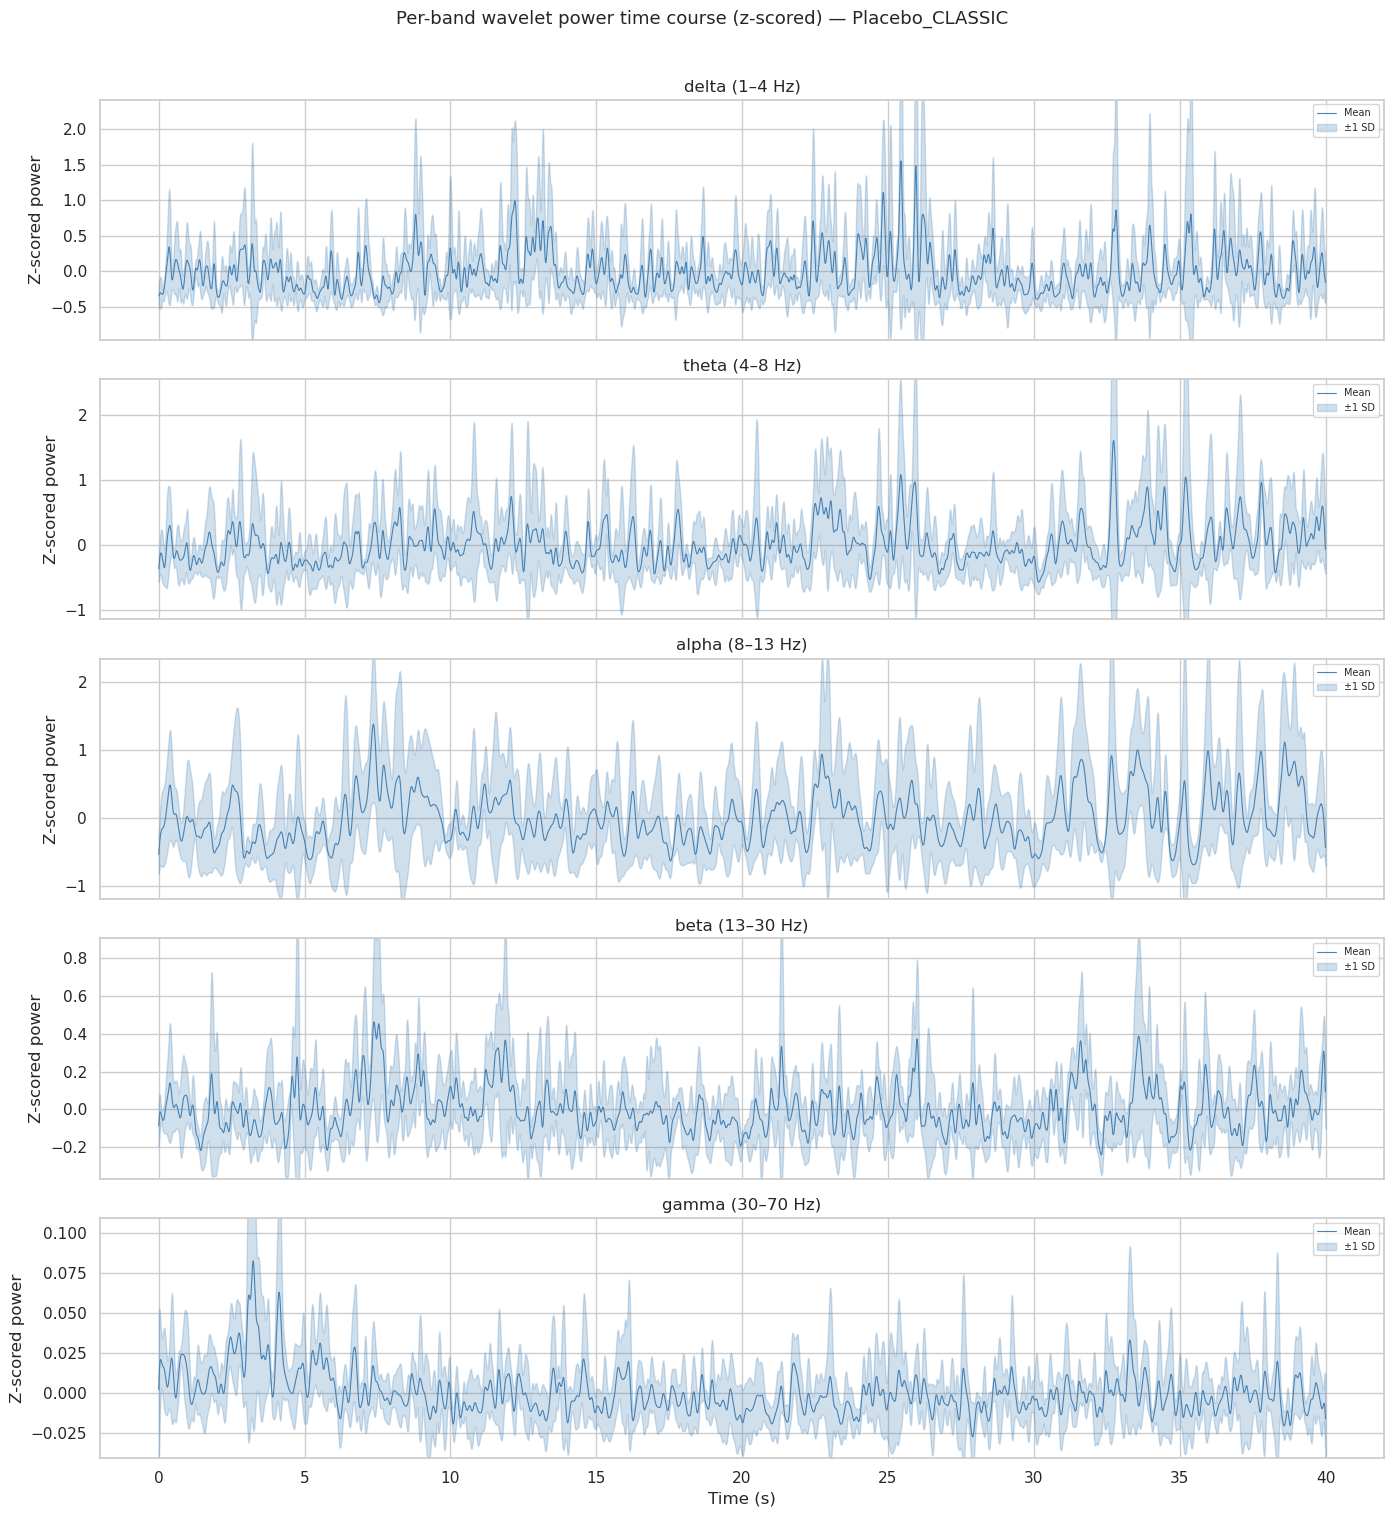

In [9]:
fig, axes = plt.subplots(
    len(FREQUENCY_BANDS), 1, figsize=(14, 3 * len(FREQUENCY_BANDS)), sharex=True
)
if len(FREQUENCY_BANDS) == 1:
    axes = [axes]

for ax, (band, (lo, hi)) in zip(axes, FREQUENCY_BANDS.items()):
    # Select frequency indices within this band
    band_mask = (FREQS >= lo) & (FREQS <= hi)
    # Average over band freqs → (n_subjects, n_channels, n_times)
    band_power = bb_data[:, :, band_mask, :].mean(axis=2)
    # Z-score across time per subject per channel (same as 01-* analyses)
    bp_mean = band_power.mean(axis=2, keepdims=True)
    bp_std = band_power.std(axis=2, keepdims=True)
    band_power_z = (band_power - bp_mean) / (bp_std + 1e-10)
    # Channel average → (n_subjects, n_times)
    band_ch_avg = band_power_z.mean(axis=1)
    group_mean = band_ch_avg.mean(axis=0)
    group_std = band_ch_avg.std(axis=0)

    # Clip to high percentile to remove outliers
    upper = np.percentile(group_mean + group_std, PLOT_PERCENTILE_CLIP)
    lower = np.percentile(group_mean - group_std, 100 - PLOT_PERCENTILE_CLIP)

    ax.plot(time, group_mean, color="steelblue", linewidth=0.8, label="Mean")
    ax.fill_between(
        time,
        group_mean - group_std,
        group_mean + group_std,
        alpha=0.25,
        color="steelblue",
        label="±1 SD",
    )
    ax.set_ylim(lower, upper)
    ax.set_ylabel("Z-scored power")
    ax.set_title(f"{band} ({lo:.0f}–{hi:.0f} Hz)")
    ax.legend(fontsize=7, loc="upper right")

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"Per-band wavelet power time course (z-scored) — {LABEL}", fontsize=13, y=1.01
)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "band_power_timecourse.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4 — Intersubject Variance in the Wavelet Domain

For each band, collapse frequencies to get `(n_subjects, n_channels, n_times)`,
then compute `compute_intersubject_stats` (same statistic as `01-*`).  Low
intersubject variance indicates frequency-resolved synchrony.

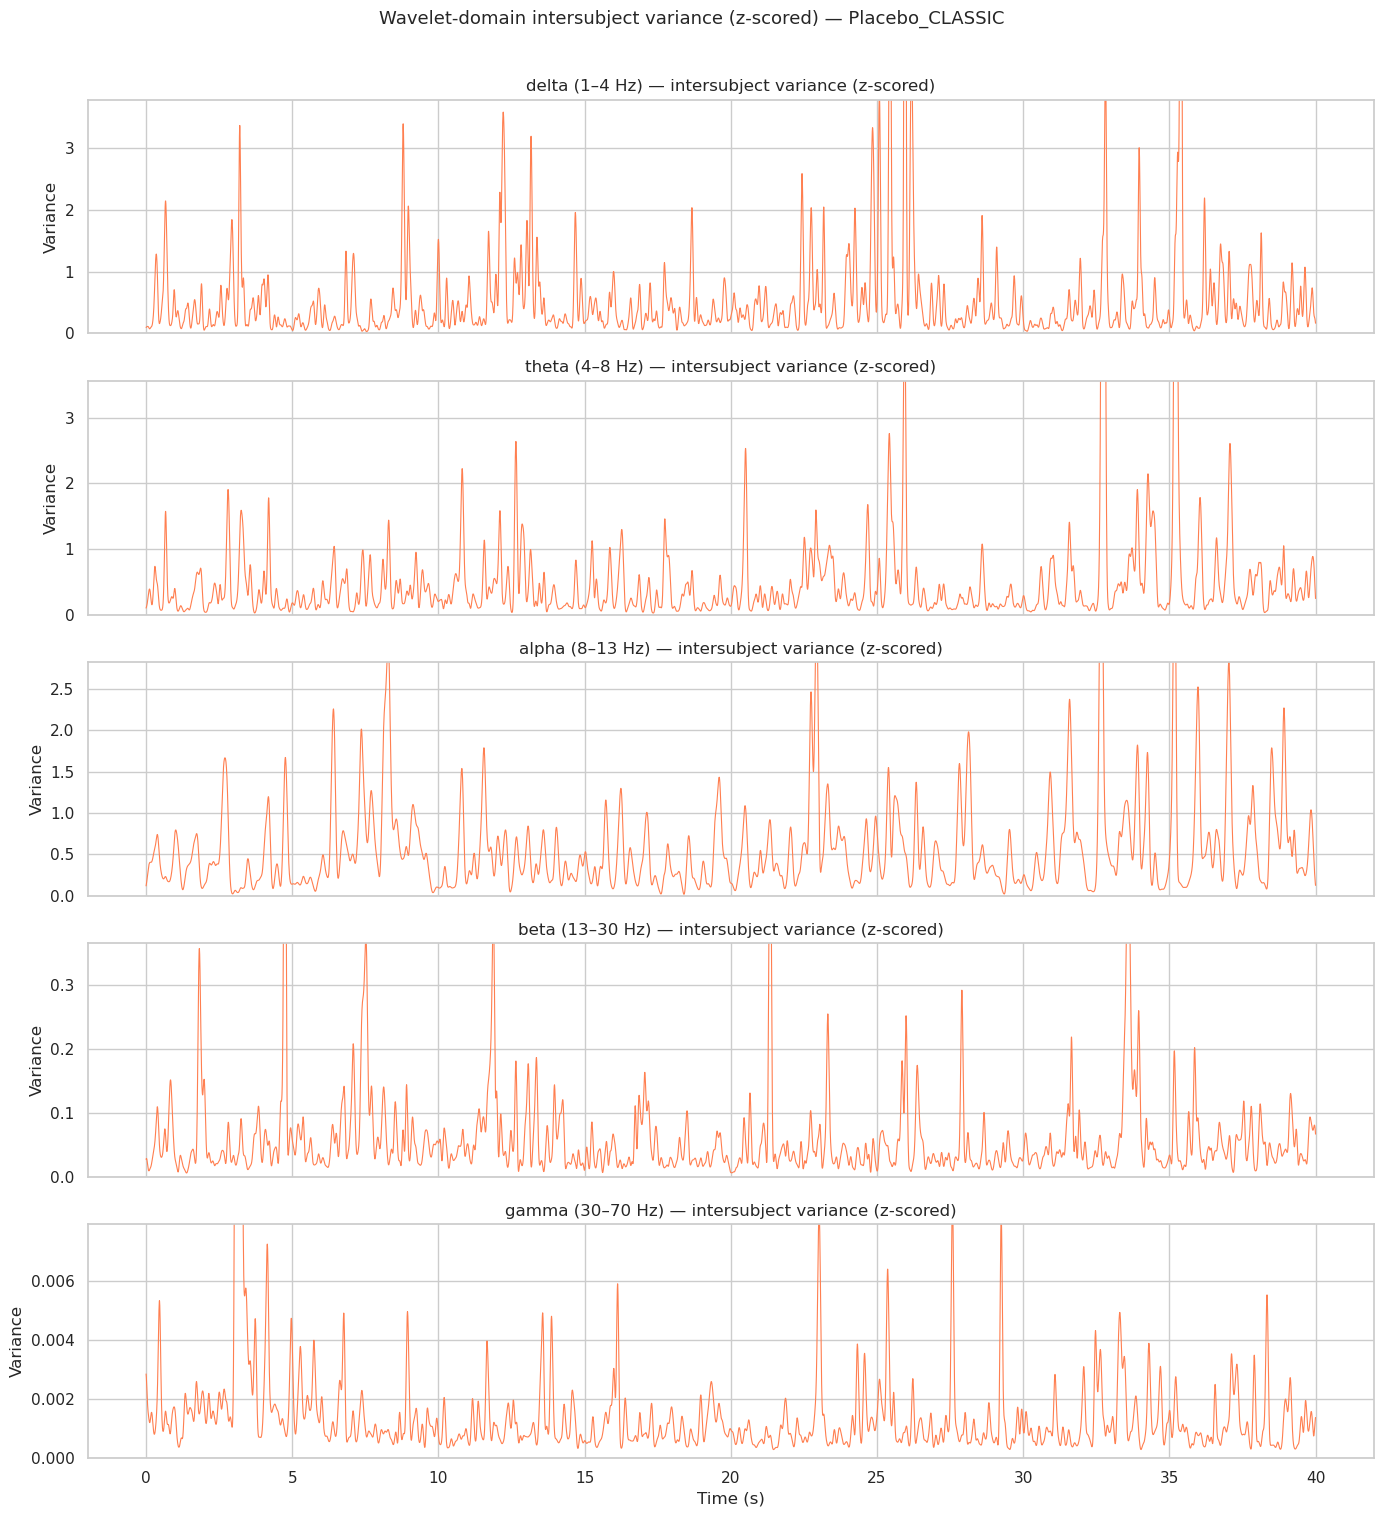

In [10]:
fig, axes = plt.subplots(
    len(FREQUENCY_BANDS), 1, figsize=(14, 3 * len(FREQUENCY_BANDS)), sharex=True
)
if len(FREQUENCY_BANDS) == 1:
    axes = [axes]

for ax, (band, (lo, hi)) in zip(axes, FREQUENCY_BANDS.items()):
    band_mask = (FREQS >= lo) & (FREQS <= hi)
    band_power_3d = bb_data[:, :, band_mask, :].mean(axis=2)  # (n_sub, n_ch, n_t)
    # Z-score across time per subject per channel (same as 01-* analyses)
    bp_mean = band_power_3d.mean(axis=2, keepdims=True)
    bp_std = band_power_3d.std(axis=2, keepdims=True)
    band_power_z = (band_power_3d - bp_mean) / (bp_std + 1e-10)
    stats = compute_intersubject_stats(band_power_z)
    var_t = stats["var_t"]  # (n_times,)

    # Clip to high percentile to remove outliers
    upper = np.percentile(var_t, PLOT_PERCENTILE_CLIP)

    ax.plot(time, var_t, color="coral", linewidth=0.8)
    ax.set_ylim(bottom=0, top=upper)
    ax.set_ylabel("Variance")
    ax.set_title(f"{band} ({lo:.0f}–{hi:.0f} Hz) — intersubject variance (z-scored)")

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"Wavelet-domain intersubject variance (z-scored) — {LABEL}",
    fontsize=13,
    y=1.01,
)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / "wavelet_intersubject_variance.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()

---
## 5 — Wavelet-Domain LOO-ISC (Per Band)

For each band, compute LOO-ISC on band-averaged power
`(n_subjects, n_channels, n_times)` — direct counterpart of `02-*` ISC but in
the wavelet domain.  We expect stimulus-tracking bands (e.g. delta/theta for
rhythm) to show higher ISC.

In [11]:
band_mean_iscs: dict[str, np.ndarray] = {}

for band, (lo, hi) in FREQUENCY_BANDS.items():
    band_mask = (FREQS >= lo) & (FREQS <= hi)
    band_power_3d = bb_data[:, :, band_mask, :].mean(axis=2)
    _, mean_loo_isc = compute_loo_isc(band_power_3d)
    band_mean_iscs[band] = mean_loo_isc  # (n_channels,)
    print(
        f"  {band:6s}  mean LOO-ISC = {mean_loo_isc.mean():.4f}"
        f"  (median = {np.median(mean_loo_isc):.4f})"
    )

  delta   mean LOO-ISC = 0.0132  (median = 0.0162)
  theta   mean LOO-ISC = -0.0002  (median = -0.0066)
  alpha   mean LOO-ISC = 0.0417  (median = 0.0379)
  beta    mean LOO-ISC = 0.0835  (median = 0.0858)
  gamma   mean LOO-ISC = 0.0514  (median = 0.0511)


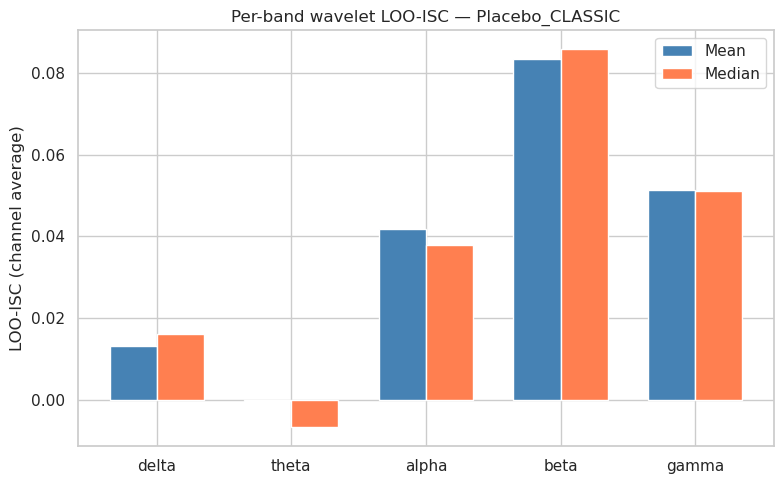

In [12]:
# Bar chart of per-band mean ISC
bands_list = list(band_mean_iscs.keys())
means = [band_mean_iscs[b].mean() for b in bands_list]
medians = [np.median(band_mean_iscs[b]) for b in bands_list]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(bands_list))
width = 0.35
ax.bar(x - width / 2, means, width, label="Mean", color="steelblue")
ax.bar(x + width / 2, medians, width, label="Median", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(bands_list)
ax.set_ylabel("LOO-ISC (channel average)")
ax.set_title(f"Per-band wavelet LOO-ISC — {LABEL}")
ax.legend()

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "wavelet_loo_isc_bar.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.1 — LOO-ISC distribution per band

Histogram of per-channel mean LOO-ISC for each band, clipped at the 99th
percentile to suppress outlier channels.

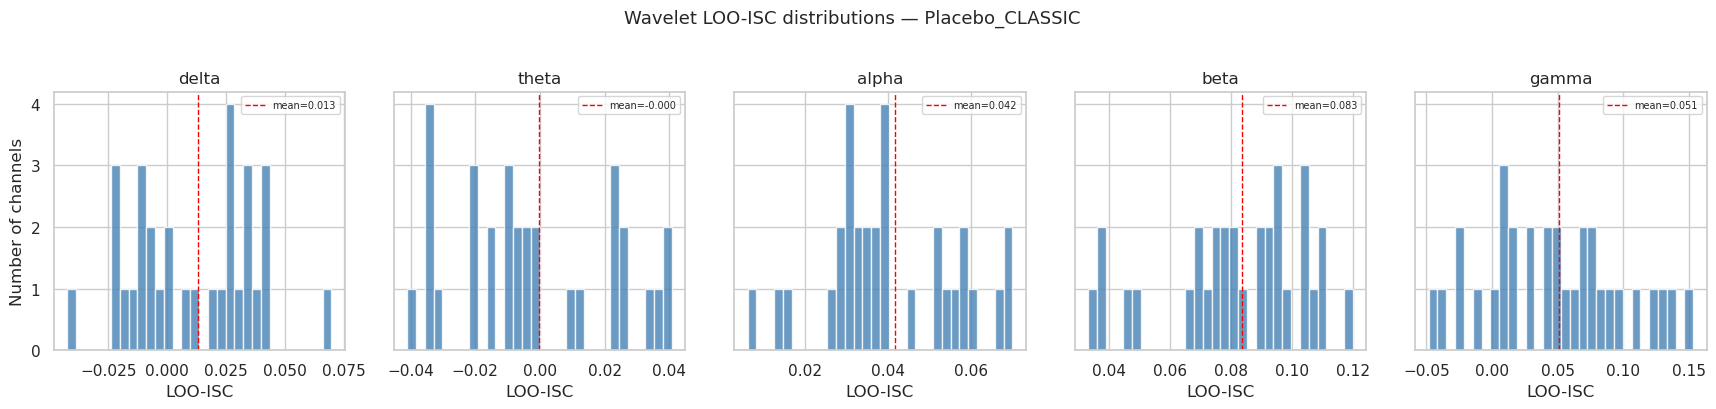

In [13]:
fig, axes = plt.subplots(
    1, len(FREQUENCY_BANDS), figsize=(3.5 * len(FREQUENCY_BANDS), 4), sharey=True
)
if len(FREQUENCY_BANDS) == 1:
    axes = [axes]

for ax, band in zip(axes, FREQUENCY_BANDS):
    vals = band_mean_iscs[band]
    clip = np.percentile(vals, 99)
    ax.hist(
        vals[vals <= clip], bins=30, color="steelblue", edgecolor="white", alpha=0.8
    )
    ax.axvline(
        vals.mean(),
        color="red",
        linestyle="--",
        linewidth=1,
        label=f"mean={vals.mean():.3f}",
    )
    ax.set_xlabel("LOO-ISC")
    ax.set_title(band)
    ax.legend(fontsize=7)

axes[0].set_ylabel("Number of channels")
fig.suptitle(f"Wavelet LOO-ISC distributions — {LABEL}", fontsize=13, y=1.02)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / "wavelet_loo_isc_distributions.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()

---
## 6 — Topographic Mapping

Project per-channel mean LOO-ISC for each frequency band onto the scalp montage.
This reveals which brain regions show the strongest frequency-specific synchrony.

Requires MNE channel position info from the loaded data.

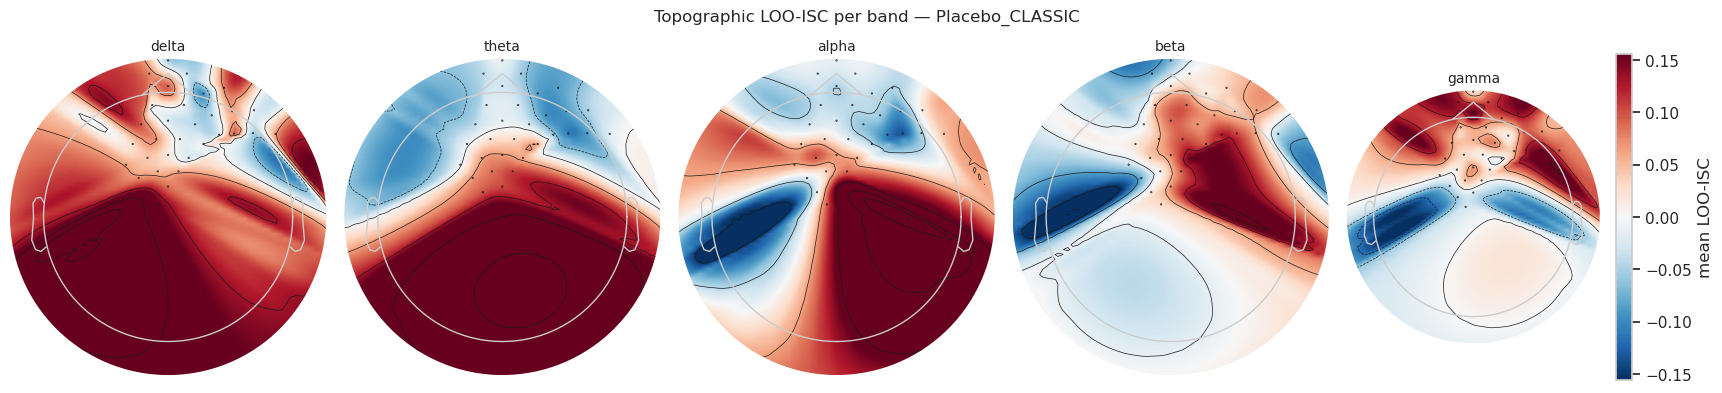

In [14]:
# Get channel info from the analyzer's MNE Info object
info = analyzers[LABEL].info
info = mne.pick_info(info, mne.pick_types(info, eeg=True))
# Subset to match the actual number of channels used (e.g. after N_CHANNELS_SUBSET)
if n_channels < len(info.ch_names):
    info = mne.pick_info(info, list(range(n_channels)))

bands_list_topo = list(FREQUENCY_BANDS.keys())
fig, axes = plt.subplots(
    1, len(bands_list_topo), figsize=(3.5 * len(bands_list_topo), 4)
)
for ax, band in zip(axes, bands_list_topo):
    if band not in band_mean_iscs:
        ax.set_visible(False)
        continue
    isc_values = band_mean_iscs[band]  # (n_channels,)
    # plot_topomap requires values to match info channels
    im, _ = plot_topomap(isc_values, info, axes=ax, show=False, cmap="RdBu_r")
    ax.set_title(band, fontsize=10)

fig.suptitle(f"Topographic LOO-ISC per band — {LABEL}", fontsize=12)
plt.colorbar(im, ax=axes[-1], label="mean LOO-ISC")
plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / f"topomap_isc_{LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7 — Time–Frequency ISC

Compute LOO-ISC at every `(frequency, time)` cell by flattening the frequency dimension
into features and applying per-feature LOO-ISC.

Result is a 2-D ISC spectrogram: `(n_freqs, n_times)`.

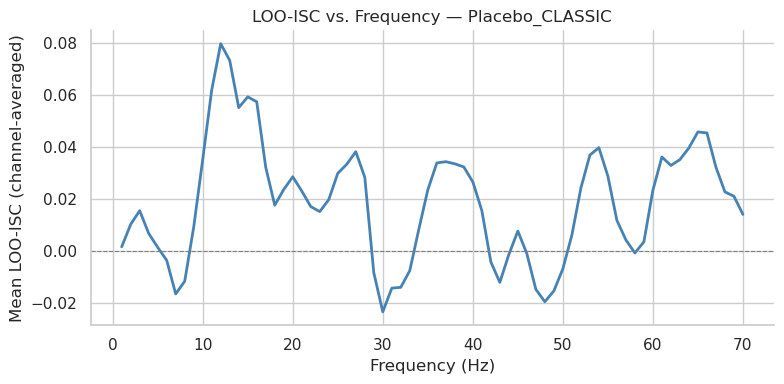

In [15]:
# Broadband data: (n_subjects, n_channels, n_freqs, n_times)
# Reshape to (n_subjects, n_channels * n_freqs, n_times) for LOO-ISC
n_subjects, n_channels, n_freqs_bb, n_times = bb_data.shape
bb_flat = bb_data.reshape(n_subjects, n_channels * n_freqs_bb, n_times)

# Compute per-(channel, freq) ISC -> (n_channels * n_freqs,)
_, tf_isc_flat = compute_loo_isc(bb_flat)

# Reshape back to (n_channels, n_freqs) then average over channels
tf_isc_ch_freq = tf_isc_flat.reshape(n_channels, n_freqs_bb)
tf_isc_freq = tf_isc_ch_freq.mean(axis=0)  # (n_freqs,)

# Also compute per-timepoint ISC via sliding approach (channel-averaged)
# Use band-averaged broadband for a TF-ISC map: compute per-band ISC per time window
# Here we do a per-time ISC heatmap using precomputed per-freq ISC (static)
FREQS_BB = FREQS  # reuse the FREQS variable defined in the config cell

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(FREQS_BB, tf_isc_freq, color="steelblue", lw=2)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Mean LOO-ISC (channel-averaged)")
ax.set_title(f"LOO-ISC vs. Frequency — {LABEL}")
sns.despine()
plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / f"tf_isc_freq_profile_{LABEL}.png", dpi=150, bbox_inches="tight"
    )
plt.show()

---
## 8 — Sliding-Window Wavelet ISC

Combines the sliding-window approach from `02-*` with frequency-resolved wavelet power.
For each band, compute LOO-ISC in successive time windows → a time-resolved ISC trace per band.

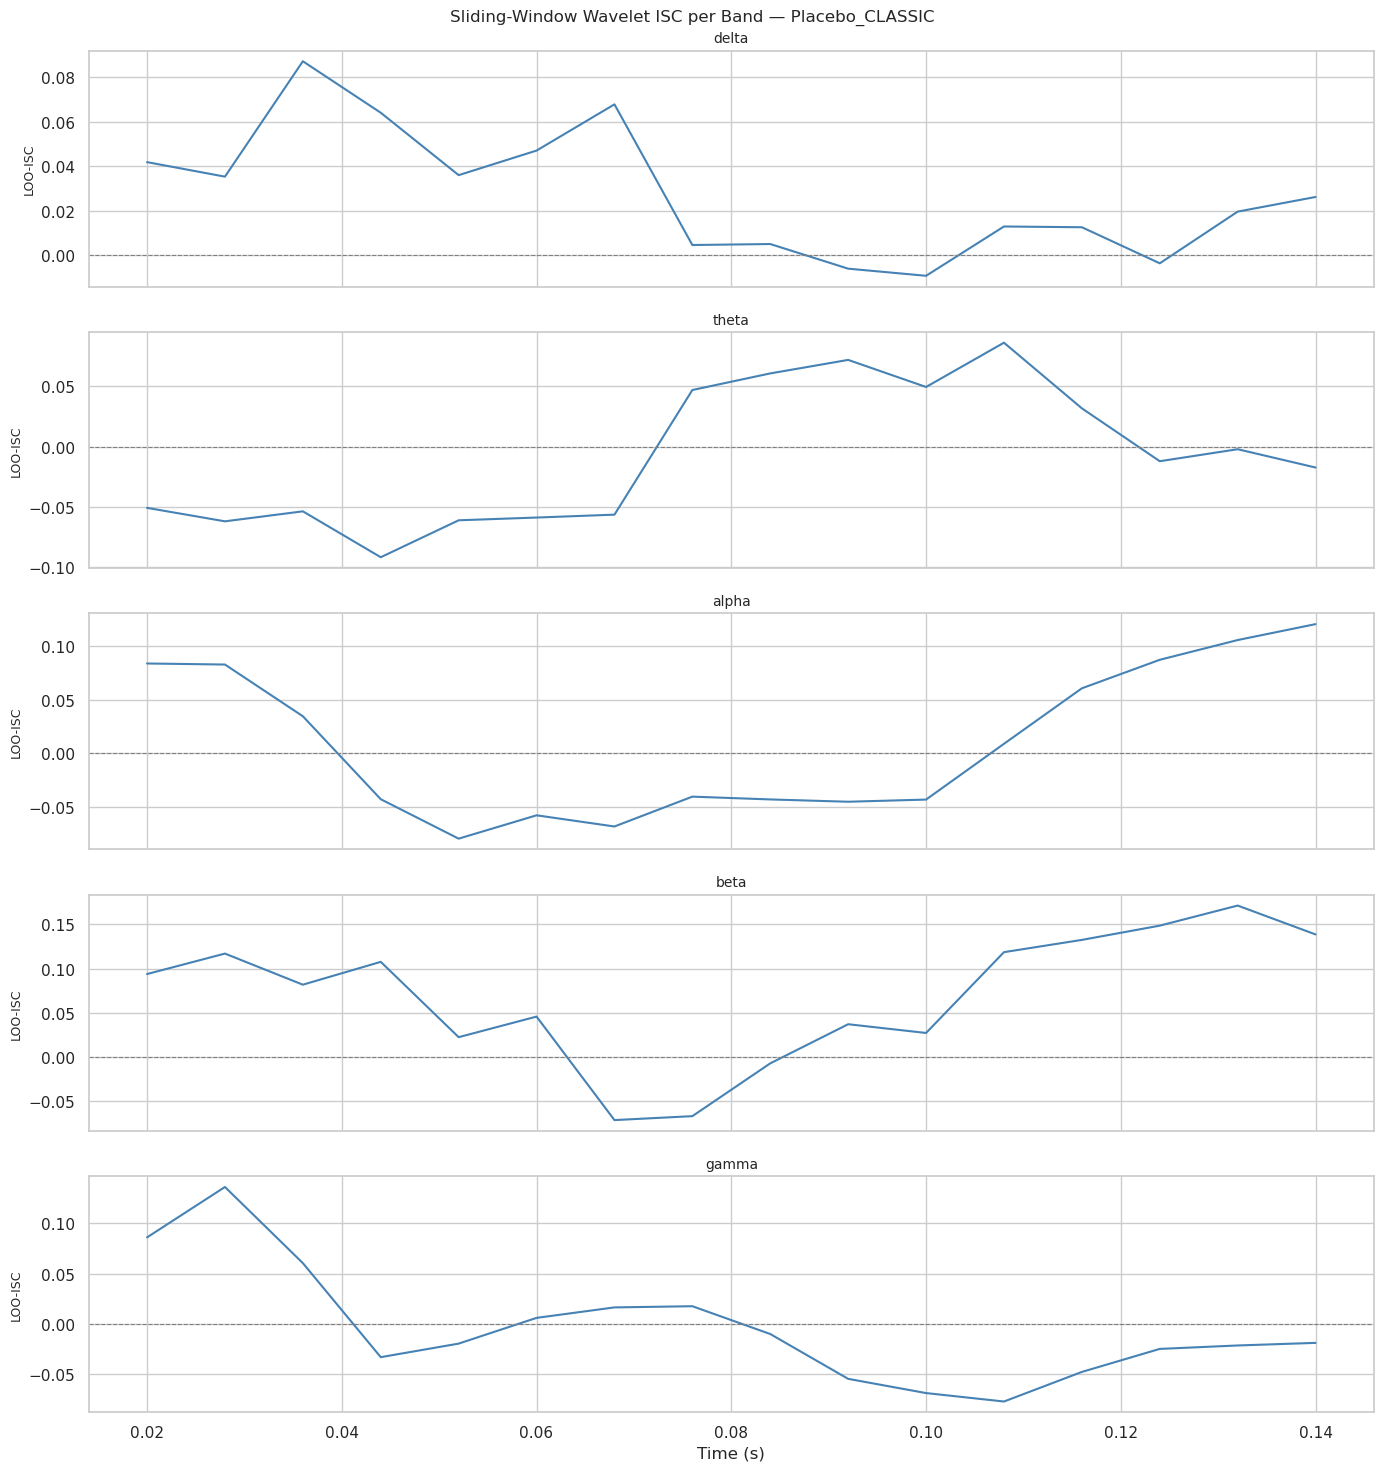

In [16]:
WINDOW_SEC = 10.0
STEP_SEC = 2.0

fig, axes = plt.subplots(
    len(FREQUENCY_BANDS), 1, figsize=(14, 3 * len(FREQUENCY_BANDS)), sharex=True
)
for ax, (band, (lo, hi)) in zip(axes, FREQUENCY_BANDS.items()):
    if band not in band_datasets or LABEL not in band_datasets[band]:
        ax.set_visible(False)
        continue
    ad = band_datasets[band][LABEL]
    # Collapse frequency dimension -> (n_subjects, n_channels, n_times)
    band_data_3d = ad.data.mean(axis=2)
    isc_tc, win_times = compute_sliding_window_isc(
        band_data_3d, window_sec=WINDOW_SEC, step_sec=STEP_SEC, sfreq=ad.sfreq
    )
    # isc_tc: (n_windows, n_channels); win_times in samples -> convert to seconds
    win_times_sec = win_times / ad.sfreq
    mean_tc = isc_tc.mean(axis=1)
    ax.plot(win_times_sec, mean_tc, lw=1.5, color="steelblue")
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_ylabel("LOO-ISC", fontsize=9)
    ax.set_title(band, fontsize=10)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"Sliding-Window Wavelet ISC per Band — {LABEL}", fontsize=12)
plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / f"sliding_window_isc_{LABEL}.png", dpi=150, bbox_inches="tight"
    )
plt.show()

---
## 9 — Cross-Frequency Coupling

Explore whether power in one band is correlated with the power in another band.
For each pair of bands, compute the Pearson correlation between their channel-averaged,
subject-mean power time courses.

A high correlation between delta and alpha power, for example, could indicate
nested oscillatory dynamics.

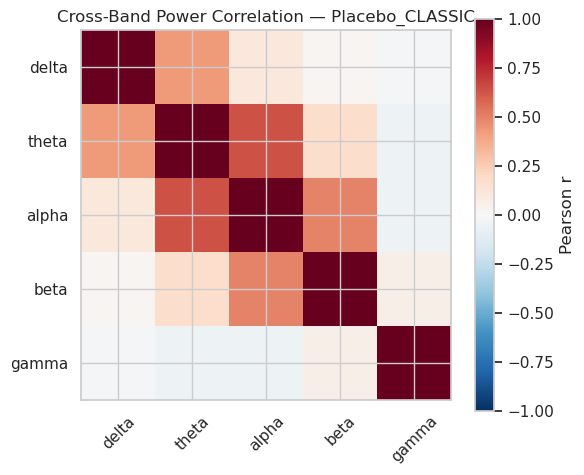

In [17]:
band_names = list(FREQUENCY_BANDS.keys())
n_bands = len(band_names)

# Build per-band mean power time course: (band, n_times)
band_power_tc: dict[str, np.ndarray] = {}
for band in band_names:
    if band not in band_datasets or LABEL not in band_datasets[band]:
        continue
    ad = band_datasets[band][LABEL]
    # Mean over subjects, channels, freqs -> (n_times,)
    band_power_tc[band] = ad.data.mean(axis=(0, 1, 2))

valid_bands = [b for b in band_names if b in band_power_tc]
n_valid = len(valid_bands)

# Compute pairwise correlation matrix
cfc_matrix = np.full((n_valid, n_valid), np.nan)
for i, b1 in enumerate(valid_bands):
    for j, b2 in enumerate(valid_bands):
        cfc_matrix[i, j] = np.corrcoef(band_power_tc[b1], band_power_tc[b2])[0, 1]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cfc_matrix, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(n_valid))
ax.set_yticks(range(n_valid))
ax.set_xticklabels(valid_bands, rotation=45)
ax.set_yticklabels(valid_bands)
ax.set_title(f"Cross-Band Power Correlation — {LABEL}")
plt.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / f"cross_freq_coupling_{LABEL}.png", dpi=150, bbox_inches="tight"
    )
plt.show()

---
## 10 — Power–Phase Joint Analysis

Overlay per-band power ISC and phase ISC to identify bands where both amplitude
and timing are synchronised vs. bands where only one modality is synchronised.

Phase ISC is approximated here as ISC computed on `cos(phase)` of the band-averaged
wavelet phase (loaded from the phase wavelet cache).

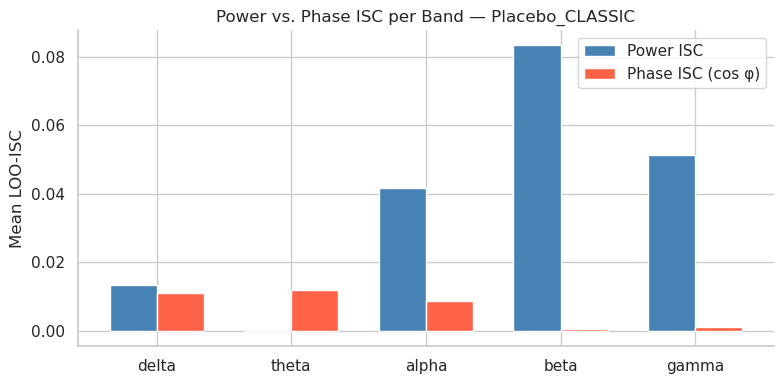

In [18]:
# Load per-band phase data (wavelet_phase representation)
phase_band_iscs: dict[str, np.ndarray] = {}
phase_wavelet_dir = WAVELET_DIR  # same top-level directory

# Phase ISC requires per-band wavelet caches; skip when only broadband
# data was computed (i.e. RUN_PER_BAND=False in the config cell).
if RUN_PER_BAND:
    for band, (lo, hi) in FREQUENCY_BANDS.items():
        band_dir = phase_wavelet_dir / f"band_{band}"
        if not band_dir.exists():
            print(f"Phase wavelet cache not found for band {band!r}, skipping.")
            continue
        phase_band_datasets_b = _wavelet_transform(
            datasets=datasets,
            freqs=np.linspace(
                lo,
                hi,
                max(2, int(round((hi - lo) / _WAVELET_BAND_FREQ_RESOLUTION_HZ)) + 1),
            ),
            representation="phase",
            keep_frequency_dim=KEEP_FREQUENCY_DIM,
            reshape_frequency_dim=RESHAPE_FREQUENCY_DIM,
            reuse_wavelets=True,
            wavelet_dir=band_dir,
        )
        if LABEL in phase_band_datasets_b:
            ph_ad = phase_band_datasets_b[LABEL]
            # cos(phase) projection then LOO-ISC
            cos_phase = np.cos(
                ph_ad.data.mean(axis=2)
            )  # mean over freqs -> (n_subj, n_ch, n_times)
            _, phase_band_iscs[band] = compute_loo_isc(cos_phase)

# Comparison bar chart
if phase_band_iscs:
    common_bands = [
        b for b in band_names if b in band_mean_iscs and b in phase_band_iscs
    ]
    power_means = [band_mean_iscs[b].mean() for b in common_bands]
    phase_means = [phase_band_iscs[b].mean() for b in common_bands]
    x = np.arange(len(common_bands))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - width / 2, power_means, width, label="Power ISC", color="steelblue")
    ax.bar(x + width / 2, phase_means, width, label="Phase ISC (cos φ)", color="tomato")
    ax.set_xticks(x)
    ax.set_xticklabels(common_bands)
    ax.set_ylabel("Mean LOO-ISC")
    ax.set_title(f"Power vs. Phase ISC per Band — {LABEL}")
    ax.legend()
    sns.despine()
    plt.tight_layout()
    if SAVE_PLOTS:
        fig.savefig(
            PLOTS_DIR / f"power_phase_joint_{LABEL}.png", dpi=150, bbox_inches="tight"
        )
    plt.show()
else:
    print("No phase wavelet cache found. Run the phase wavelet pipeline first.")

---
## Summary

The arrays are available for further analysis:

- `broadband_datasets[LABEL].data` — 4-D broadband wavelet power
- `band_datasets[band][LABEL].data` — 4-D per-band wavelet power
- `band_mean_iscs[band]` — per-channel LOO-ISC for each band

Analyses implemented in this notebook:

1. Grand-average spectral profile
2. Time–frequency map (spectrogram)
3. Per-band power time course
4. Intersubject variance in the wavelet domain
5. Wavelet-domain LOO-ISC per band
6. Topographic mapping of per-band LOO-ISC
7. Time–frequency ISC (LOO-ISC vs. frequency profile)
8. Sliding-window wavelet ISC per band
9. Cross-frequency coupling (band-power correlation matrix)
10. Power–phase joint analysis (power ISC vs. phase ISC per band)

See `README.md` in this directory for ideas on extending these analyses
(Placebo vs. Psilocybin condition comparison, permutation-based statistical testing, etc.).